In [ ]:
# set seeds for reproducibility
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(0)

In [ ]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers,models

In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
kaggle_credentails =json.load(open("kaggle (2).json"))

In [ ]:
# setup kaggle API key as enviroment variables
os.environ["KAGGLE_USERNAME"] = kaggle_credentails["username"]
os.environ["KAGGLE_KEY"] = kaggle_credentails["key"]


In [ ]:
%pip install kaggle

import os, shutil, zipfile

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
shutil.copy("kaggle (2).json", os.path.expanduser("~/.kaggle/kaggle (2).json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle (2).json"), 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset

with zipfile.ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("plantvillage_dataset")

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

 84%|████████▎ | 1.70G/2.04G [00:00<?, ?B/s]
 84%|████████▎ | 1.71G/2.04G [00:01<10:00, 597kB/s]
 84%|████████▎ | 1.71G/2.04G [00:02<06:28, 921kB/s]
 84%|████████▎ | 1.71G/2.04G [00:03<06:05, 976kB/s]
 84%|████████▍ | 1.71G/2.04G [00:04<06:01, 984kB/s]
 84%|████████▍ | 1.71G/2.04G [00:05<06:46, 872kB/s]
 84%|████████▍ | 1.71G/2.04G [00:06<06:08, 959kB/s]
 84%|████████▍ | 1.71G/2.04G [00:07<05:55, 991kB/s]
 84%|████████▍ | 1.71G/2.04G [00:08<05:58, 980kB/s]
 84%|████████▍ | 1.71G/2.04G [00:10<06:10, 945kB/s]
 84%|████████▍ | 1.71G/2.04G [00:11<06:34, 885kB/s]
 84%|████████▍ | 1.71G/2.04G [00:12<06:25, 904kB/s]
 84%|████████▍ | 1.72G/2.04G [00:13<06:39, 870kB/s]
 84%|████████▍ | 1.72G/2.04G [00:15<07:06, 811kB/s]
 84%|████████▍ | 1.72G/2.04G [00:16<07:17, 788kB/s]
 84%|████████▍ | 1.72G/2.04G [00:18<07:33, 758kB/s]
 84%|████████▍ | 1.72G/2.04G [00:20<06:29, 877kB/

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Resuming from 1829765120 bytes (359621299 bytes left)...



In [ ]:
# unzip the downloaded dataset
with ZipFile("plantvillage-dataset.zip","r") as zip:
  zip.extractall()

In [ ]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])


['color', 'grayscale', 'segmented']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [ ]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_HL 6067.JPG', '0163a6aa-fbf8-47c5-965f-59b6efe8bfe5___Mt.N.V_HL 6103.JPG', '0294ca65-4c29-44be-af28-501df9f715e8___Mt.N.V_HL 6176.JPG', '02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_HL 9078.JPG', '03027791-26bb-4c46-960e-8df76e27042c___Mt.N.V_HL 6070.JPG']


In [ ]:
#Dataset Path
base_dir = "plantvillage dataset/color"

(256, 256, 3)


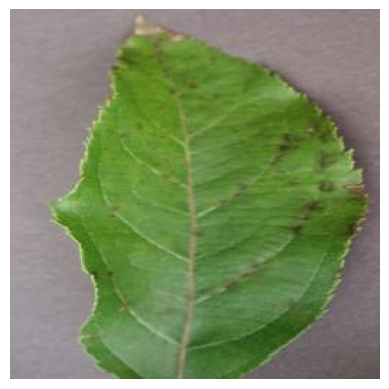

In [ ]:
image_path ="C:\\Users\\gargi\\OneDrive\\Desktop\\plant di\\plantvillage dataset\\color\\Apple___Apple_scab\\0a5e9323-dbad-432d-ac58-d291718345d9___FREC_Scab 3417.JPG"
# Read the image
img =mpimg.imread(image_path)
print(img.shape)
# Display the image
plt.imshow(img)
plt.axis("off") #Turn off axis numbers
plt.show()

In [ ]:
#Image Parameters
img_size =224
batch_size =32

Train Test Split

In [ ]:
# Image Dta Generators
data_gen = ImageDataGenerator(
    rescale=1./225,
    validation_split=0.2 #Use 20% of data for validation
)

In [ ]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [ ]:
train_generator.num_classes

38

Convolutional Neural Network

In [ ]:
# Model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape= (img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64,(3, 3), activation= "relu"))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(250, activation="relu"))
model.add(layers.Dense(train_generator.num_classes, activation="softmax"))

c:\Users\gargi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# model Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 250)            │    46,656,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,538 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,685,180 (178.09 MB)

 Trainable params: 46,685,180 (178.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the Model
model.compile(optimizer= "adam",
   loss= "categorical_crossentropy",
              metrics=["accuracy"]
)

Double-click (or enter) to edit

Model Training

In [ ]:
# Training the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,  # Number of steps per epoch
    epochs=5,  # Number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size  # validation steps
)

c:\Users\gargi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 4388s 3s/step - accuracy: 0.7305 - loss: 0.9701 - val_accuracy: 0.8554 - val_loss: 0.4716
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1850s 1s/step - accuracy: 0.9137 - loss: 0.2697 - val_accuracy: 0.8751 - val_loss: 0.4088
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1674s 1s/step - accuracy: 0.9592 - loss: 0.1251 - val_accuracy: 0.8921 - val_loss: 0.4025
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1799s 1s/step - accuracy: 0.9735 - loss: 0.0797 - val_accuracy: 0.8765 - val_loss: 0.5137
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 2011s 1s/step - accuracy: 0.9795 - loss: 0.0636 - val_accuracy: 0.8815 - val_loss: 0.5578


In [ ]:
# Model Evaluation
print("Evaluation model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples// batch_size)
print(f"validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluation model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 105s 297ms/step - accuracy: 0.0407 - loss: 3.6389
validation Accuracy: 4.07%


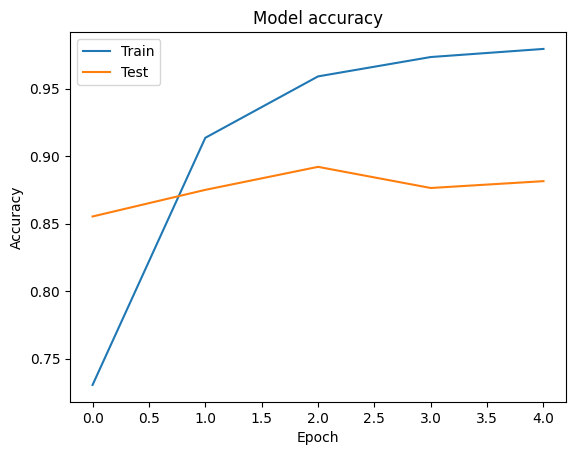

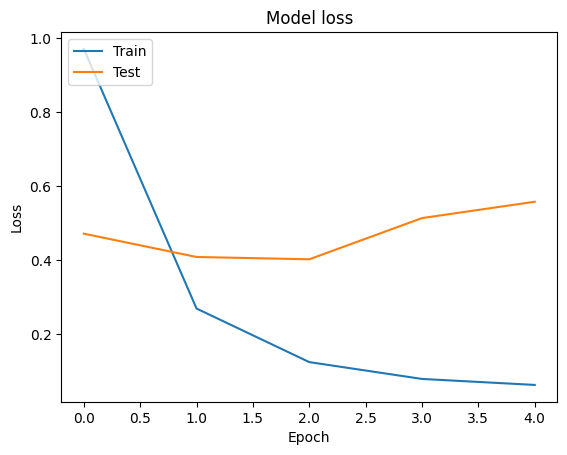

In [ ]:
# plot training & validation accuracy values
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Test"], loc= "upper left")
plt.show()

# plot training & validation loss values
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train","Test"],loc="upper left")
plt.show()

Building a Predictive System

In [ ]:
from PIL import Image
import numpy as np

# Function to preprocess image
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img = img.convert("RGB")
    img = img.resize(target_size)

    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype("float32") / 255.0

    return img_array

# Function to predict
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)

    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]

    return predicted_class_name

In [ ]:
# create a mapping from class indices to class names
class_indices ={v: k for k, v in train_generator.class_indices.items()}

In [ ]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [ ]:
#saving the class names as json file
json.dump(class_indices, open("class_indices.json", "w"))

In [ ]:
#example usage
#image_path = "/content/test_apple_black_rot.jpg"
#image_path = "/content/test_blueberry_healthy.jpg"
image_path = r"C:\Users\gargi\OneDrive\Desktop\plant di\plantvillage dataset\test_apple_black_rot.JPG"

predicted_class_name = predict_image_class(model, image_path, class_indices)

print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
Predicted Class Name: Apple___Black_rot


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


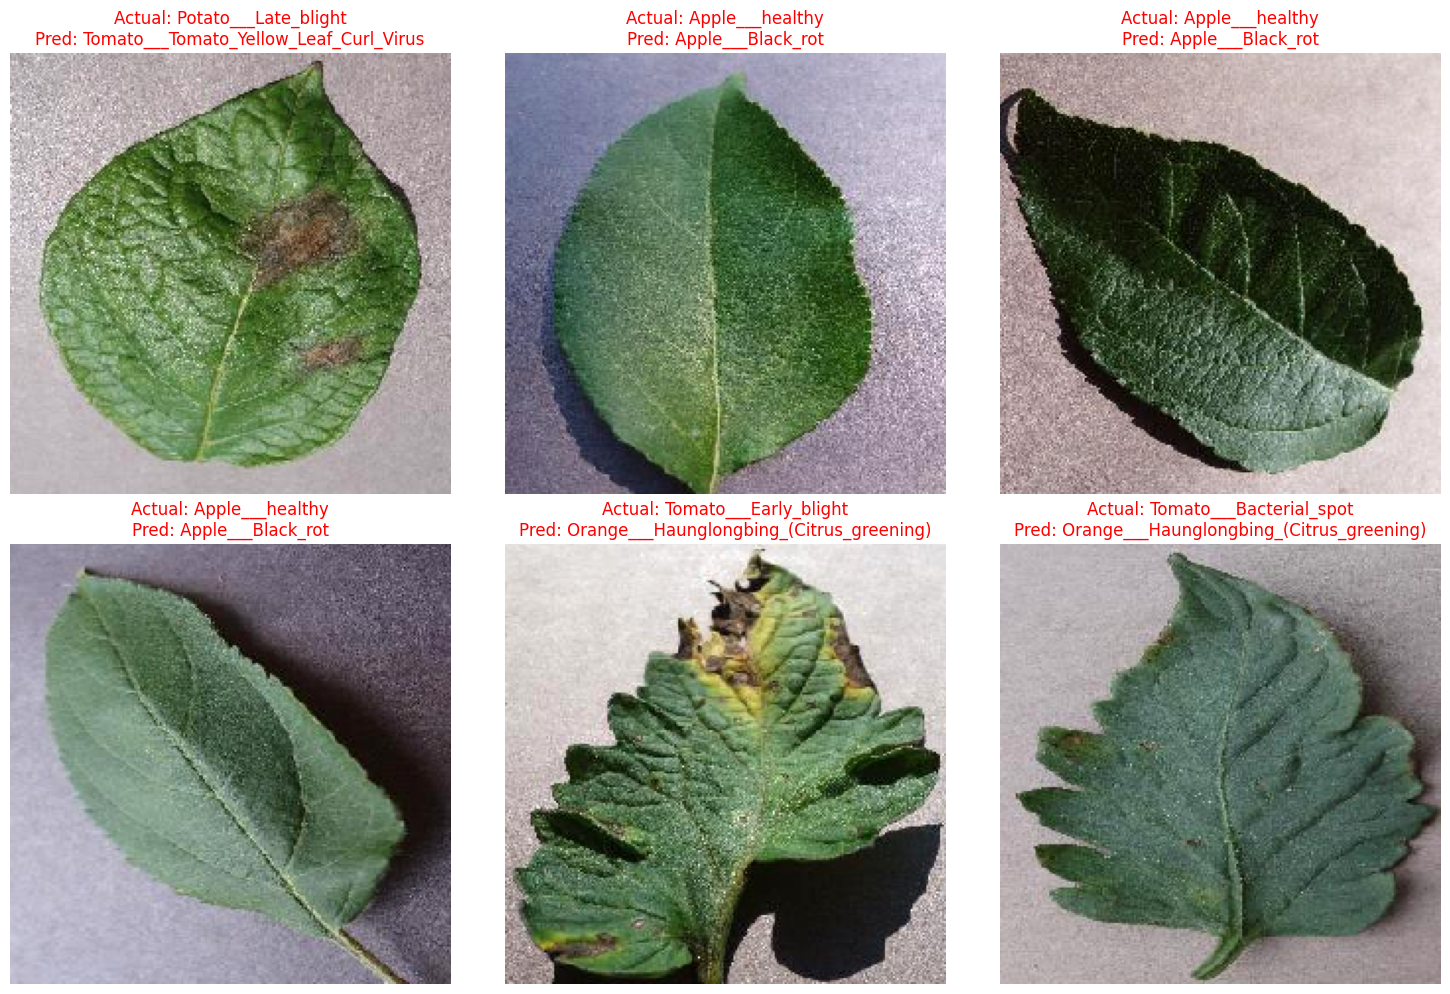

In [ ]:
import matplotlib.pyplot as plt

# 1. Get a batch of images and labels from the validation generator
# This pulls the next 32 images (one batch)
val_images, val_labels = next(validation_generator)

# 2. Get the class names (keys) from the dictionary
class_names = list(train_generator.class_indices.keys())

# 3. Predict the whole batch
predictions = model.predict(val_images)

# 4. Plot 6 images to see how it's doing
plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(val_images[i])
    
    # Get the actual class and predicted class
    actual_class = class_names[np.argmax(val_labels[i])]
    predicted_class = class_names[np.argmax(predictions[i])]
    
    # Set title color: Green if correct, Red if wrong
    title_color = 'green' if actual_class == predicted_class else 'red'
    
    plt.title(f"Actual: {actual_class}\nPred: {predicted_class}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
list(train_generator.class_indices.keys())

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_